# Euclidean vs Manhattan Distance in Machine Learning

**An Educational Exploration of Distance Metrics and Their Impact on ML Models**

This notebook demonstrates the fundamental differences between **Euclidean (L2)** and **Manhattan (L1)** distance metrics, their geometric intuition, mathematical formulation, and empirical impact on common machine learning algorithms.

## 1. Introduction: What Are Distance Metrics in Machine Learning?

**Distance metrics** (or distance functions) measure how "far apart" two data points are in feature space. They are the backbone of many ML algorithms that rely on **similarity** or **proximity** between instances.

### Why Distance Functions Matter

- **Classification**: K-Nearest Neighbors (KNN) classifies by majority vote of the *k* closest points — "closest" is defined by the chosen distance.
- **Clustering**: K-Means, DBSCAN, and hierarchical clustering group points that are "near" each other.
- **Recommendation systems**: User/item similarity is often computed via distance in a latent space.
- **Anomaly detection**: Outliers are points that are *far* from normal clusters.

**The choice of distance metric directly affects which points are considered "neighbors" and thus changes model predictions and cluster shapes.**

### Algorithms That Rely on Distance

| Algorithm | Typical distance | Role of distance |
|-----------|------------------|------------------|
| **KNN** | Euclidean (default), Manhattan, Minkowski | Find k nearest neighbors for classification/regression |
| **K-Means** | Euclidean (squared) | Assign points to nearest centroid; minimize within-cluster variance |
| **DBSCAN** | Euclidean, Manhattan | Density-based clustering via ε-neighborhoods |
| **Recommendation systems** | Cosine, Euclidean | Similarity between users/items |
| **Anomaly detection** | Euclidean, Mahalanobis | Distance to "normal" cluster centers |

### The Two Focus Metrics

#### Euclidean Distance (L2 Norm)

For two points **x** = (x₁, x₂, ..., xₙ) and **y** = (y₁, y₂, ..., yₙ) in n-dimensional space:

$$d(x, y) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

- **Intuition**: The **straight-line distance** between two points (as the crow flies).
- **Geometry**: Shortest path in "free" space; natural for continuous, real-valued features.

#### Manhattan Distance (L1 Norm)

$$d(x, y) = \sum_{i=1}^{n} |x_i - y_i|$$

- **Intuition**: The **grid path distance** — like walking along city blocks. You can only move along axes (e.g., north/south, east/west).
- **Geometry**: Sum of absolute differences along each dimension; often more robust to outliers than L2.

**In summary**: Euclidean = straight line; Manhattan = city-block path. The choice changes which points are considered "nearest" and thus affects KNN, K-Means, and other distance-based models.

In [14]:
# Import libraries for the entire notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from matplotlib.colors import ListedColormap
import warnings
warnings.filterwarnings('ignore')

# Set style for consistent, publication-ready plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 6)
%matplotlib inline

## 2. Visual Intuition: Euclidean vs Manhattan Paths

Below we plot two points in 2D and draw:
- **Euclidean path**: A straight line (shortest geometric distance).
- **Manhattan path**: A path that moves only along the axes (like walking on a grid of city blocks).

This illustrates why Manhattan distance is always **≥** Euclidean distance for the same pair of points.

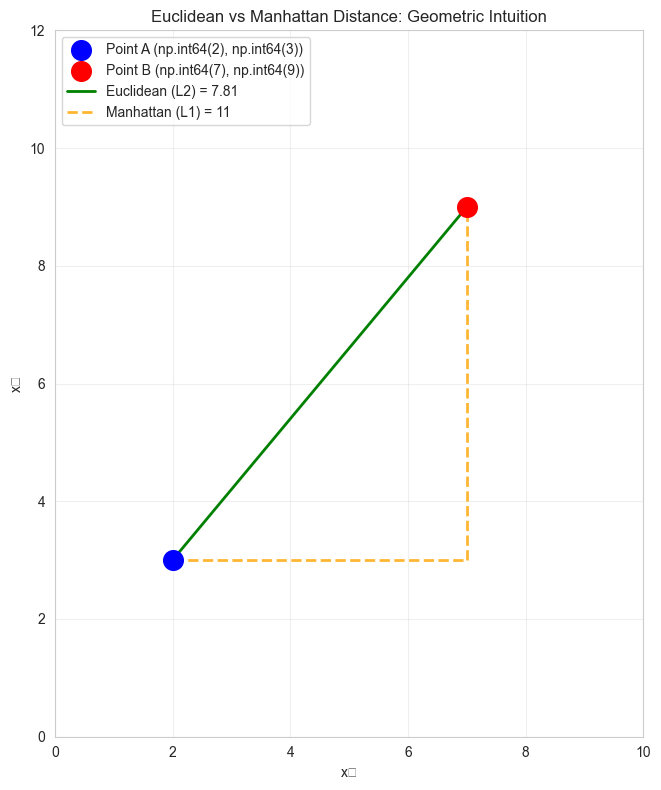

Euclidean distance: 7.8102
Manhattan distance: 11
Manhattan ≥ Euclidean always (equality only when path is along one axis).


In [15]:
# Two points in 2D: A and B
A = np.array([2, 3])
B = np.array([7, 9])

# Compute distances
euclidean_dist = np.linalg.norm(B - A)  # L2 norm
manhattan_dist = np.sum(np.abs(B - A))  # L1 norm

fig, ax = plt.subplots(figsize=(8, 8))

# Plot points
ax.scatter(*A, color='blue', s=200, zorder=5, label=f'Point A {tuple(A)}')
ax.scatter(*B, color='red', s=200, zorder=5, label=f'Point B {tuple(B)}')

# Euclidean path: straight line
ax.plot([A[0], B[0]], [A[1], B[1]], 'g-', linewidth=2, label=f'Euclidean (L2) = {euclidean_dist:.2f}')

# Manhattan path: first horizontal, then vertical
ax.plot([A[0], B[0]], [A[1], A[1]], 'orange', linewidth=2, linestyle='--', alpha=0.8)
ax.plot([B[0], B[0]], [A[1], B[1]], 'orange', linewidth=2, linestyle='--', alpha=0.8, 
        label=f'Manhattan (L1) = {manhattan_dist:.0f}')

ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.set_title('Euclidean vs Manhattan Distance: Geometric Intuition')
ax.legend(loc='upper left')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Euclidean distance: {euclidean_dist:.4f}")
print(f"Manhattan distance: {manhattan_dist}")
print("Manhattan ≥ Euclidean always (equality only when path is along one axis).")

## 3. Distance Comparison Example

**Given:** Point A = (2, 3) and Point B = (7, 9)

We compute both distances **mathematically** and **with Python**.

### Mathematical Calculation

**Euclidean (L2):**
$$d(A, B) = \sqrt{(7-2)^2 + (9-3)^2} = \sqrt{25 + 36} = \sqrt{61} \approx 7.81$$

**Manhattan (L1):**
$$d(A, B) = |7-2| + |9-3| = 5 + 6 = 11$$

In [16]:
# Same points: A = (2, 3), B = (7, 9)
A = np.array([2, 3])
B = np.array([7, 9])

# Euclidean: sqrt(sum of squared differences)
euclidean = np.sqrt(np.sum((B - A) ** 2))
print("Euclidean distance (Python):", euclidean)
print("Euclidean (formula check):  ", np.sqrt(61))

# Manhattan: sum of absolute differences
manhattan = np.sum(np.abs(B - A))
print("\nManhattan distance (Python):", manhattan)
print("Manhattan (formula check):   ", 5 + 6)

Euclidean distance (Python): 7.810249675906654
Euclidean (formula check):   7.810249675906654

Manhattan distance (Python): 11
Manhattan (formula check):    11


## 4. Effect on Machine Learning Model: K-Nearest Neighbors (KNN)

KNN classifies a point by the **majority label** among its *k* nearest neighbors. The **distance metric** determines which points are "nearest," so changing from Euclidean to Manhattan can change the decision boundary and accuracy.

We will:
1. Generate synthetic data with `make_blobs`
2. Train KNN with `metric="euclidean"` and `metric="manhattan"`
3. Plot decision boundaries for both
4. Compare accuracy

In [17]:
# Generate synthetic 2D dataset with 3 blobs (classes)
X, y = make_blobs(n_samples=300, centers=3, n_features=2, cluster_std=1.2, random_state=42)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train KNN with Euclidean and Manhattan
k = 15
knn_euclidean = KNeighborsClassifier(n_neighbors=k, metric='euclidean').fit(X_train, y_train)
knn_manhattan = KNeighborsClassifier(n_neighbors=k, metric='manhattan').fit(X_train, y_train)

# Accuracy on test set
acc_euc = accuracy_score(y_test, knn_euclidean.predict(X_test))
acc_man = accuracy_score(y_test, knn_manhattan.predict(X_test))
print(f"KNN (Euclidean) accuracy: {acc_euc:.4f}")
print(f"KNN (Manhattan) accuracy: {acc_man:.4f}")

KNN (Euclidean) accuracy: 1.0000
KNN (Manhattan) accuracy: 1.0000


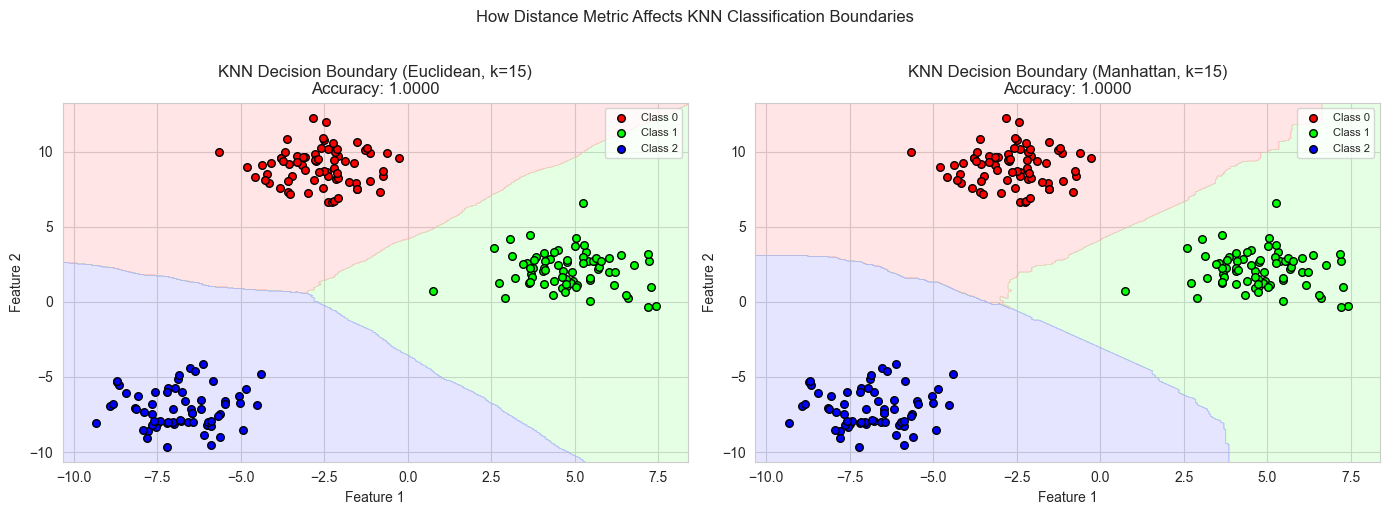

→ Different metrics yield different decision boundaries; compare accuracies above to see which fits this dataset better.


In [18]:
def plot_decision_boundary(X, y, model, title, ax):
    """Plot decision boundary for a 2D KNN classifier."""
    h = 0.05  # step size in mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
    cmap_bold = ['#FF0000', '#00FF00', '#0000FF']
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    for i in range(len(np.unique(y))):
        idx = y == i
        ax.scatter(X[idx, 0], X[idx, 1], c=cmap_bold[i], edgecolors='k', s=30, label=f'Class {i}')
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend(loc='best', fontsize=8)

# Plot decision boundaries side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_decision_boundary(X_train, y_train, knn_euclidean, f'KNN Decision Boundary (Euclidean, k={k})\nAccuracy: {acc_euc:.4f}', ax1)
plot_decision_boundary(X_train, y_train, knn_manhattan, f'KNN Decision Boundary (Manhattan, k={k})\nAccuracy: {acc_man:.4f}', ax2)
plt.suptitle('How Distance Metric Affects KNN Classification Boundaries', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
# Brief interpretation: decision boundaries can differ; accuracy may be similar or one metric may suit the data better.
print("→ Different metrics yield different decision boundaries; compare accuracies above to see which fits this dataset better.")

## 5. Effect on High-Dimensional Data

In high dimensions (e.g., 20+ features), distance metrics behave differently. We generate a high-dimensional dataset, find nearest neighbors using both Euclidean and Manhattan, and show how the **ranking of neighbors** can change. We then use **PCA** to project to 2D and visualize which points were selected as neighbors under each metric.

*Note: In the 2D PCA projection, "closeness" may look different from the original 25D space; the plots illustrate that the two metrics can select different point sets as neighbors.*

In [19]:
# High-dimensional data: 25 features, 200 samples
np.random.seed(42)
n_samples, n_features = 200, 25
X_high = np.random.randn(n_samples, n_features)
# Pick a query point (first sample)
query_idx = 0
query_point = X_high[query_idx].reshape(1, -1)
X_rest = np.delete(X_high, query_idx, axis=0)

# Nearest neighbors: Euclidean vs Manhattan (use k_neighbors to avoid overwriting k from KNN section)
from sklearn.neighbors import NearestNeighbors
k_neighbors = 5
nn_euc = NearestNeighbors(n_neighbors=k_neighbors, metric='euclidean').fit(X_rest)
nn_man = NearestNeighbors(n_neighbors=k_neighbors, metric='manhattan').fit(X_rest)

dist_euc, idx_euc = nn_euc.kneighbors(query_point)
dist_man, idx_man = nn_man.kneighbors(query_point)

print("Indices of 5 nearest neighbors (Euclidean):", idx_euc[0])
print("Indices of 5 nearest neighbors (Manhattan):", idx_man[0])
# Indices refer to X_rest (query point removed)
overlap = len(set(idx_euc[0]) & set(idx_man[0]))
print(f"\nOverlap: {overlap} out of {k_neighbors} neighbors are the same under both metrics.")
only_euc = set(idx_euc[0]) - set(idx_man[0])
only_man = set(idx_man[0]) - set(idx_euc[0])
if only_euc or only_man:
    print("Neighbors only in Euclidean set:", only_euc if only_euc else "—")
    print("Neighbors only in Manhattan set:", only_man if only_man else "—")

Indices of 5 nearest neighbors (Euclidean): [ 84 197  41 109 172]
Indices of 5 nearest neighbors (Manhattan): [197  59  84 172  98]

Overlap: 3 out of 5 neighbors are the same under both metrics.
Neighbors only in Euclidean set: {np.int64(41), np.int64(109)}
Neighbors only in Manhattan set: {np.int64(98), np.int64(59)}


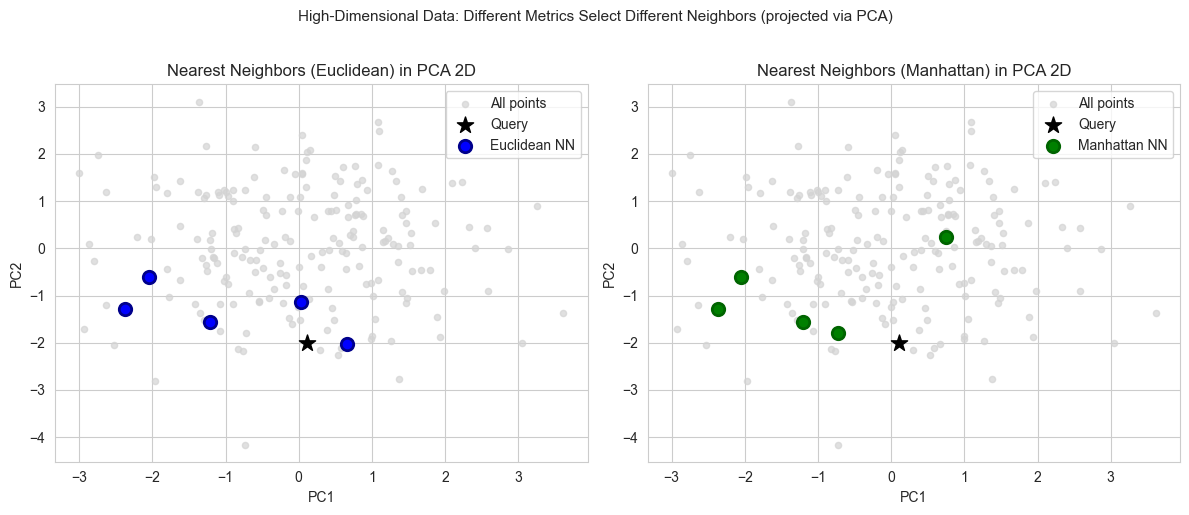

In [20]:
# PCA to 2D for visualization; highlight query and neighbors
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_high)
query_2d = X_2d[query_idx]
# X_rest was X_high with row query_idx removed, so X_rest[i] = X_high[i+1] for i >= 0
# So neighbor index in X_rest -> original index in X_high: orig = rest_idx + 1 (when query_idx=0)
orig_euc = [i + 1 for i in idx_euc[0]]
orig_man = [i + 1 for i in idx_man[0]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# All points in 2D
ax1.scatter(X_2d[:, 0], X_2d[:, 1], c='lightgray', s=20, alpha=0.7, label='All points')
ax1.scatter(*query_2d, c='black', s=150, marker='*', label='Query', zorder=5)
for i in orig_euc:
    ax1.scatter(X_2d[i, 0], X_2d[i, 1], c='blue', s=80, edgecolors='darkblue', linewidths=2, label='Euclidean NN' if i == orig_euc[0] else '')
ax1.set_title('Nearest Neighbors (Euclidean) in PCA 2D')
ax1.legend()
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')

ax2.scatter(X_2d[:, 0], X_2d[:, 1], c='lightgray', s=20, alpha=0.7, label='All points')
ax2.scatter(*query_2d, c='black', s=150, marker='*', label='Query', zorder=5)
for i in orig_man:
    ax2.scatter(X_2d[i, 0], X_2d[i, 1], c='green', s=80, edgecolors='darkgreen', linewidths=2, label='Manhattan NN' if i == orig_man[0] else '')
ax2.set_title('Nearest Neighbors (Manhattan) in PCA 2D')
ax2.legend()
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
plt.suptitle('High-Dimensional Data: Different Metrics Select Different Neighbors (projected via PCA)', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 6. K-Means (Euclidean) vs L1 Clustering (K-Medians)

**K-Means** uses Euclidean distance: it minimizes the sum of *squared* distances to cluster centers (centroids are means). In high-level terms, it assumes "spherical" clusters.

**K-Medians** (or L1 clustering) uses Manhattan distance: centroids are *medians* of assigned points, and the objective is sum of absolute distances. This tends to produce more axis-aligned, "diamond-shaped" Voronoi regions and is more robust to outliers.

Below we run **K-Means** (Euclidean) and a **K-Medians**-style clustering (assign by Manhattan distance, update center as median) on the same blob data and visualize how cluster shapes differ.

In [21]:
# K-Medians: assign by Manhattan distance, centroid = median of cluster
def k_medians_fit(X, n_clusters=3, max_iters=100, random_state=42):
    np.random.seed(random_state)
    n_samples = X.shape[0]
    # Initialize centroids as random points from X
    idx = np.random.choice(n_samples, n_clusters, replace=False)
    centroids = X[idx].copy()
    for _ in range(max_iters):
        # Assign each point to nearest centroid (Manhattan distance)
        dists = np.zeros((n_samples, n_clusters))
        for c in range(n_clusters):
            dists[:, c] = np.sum(np.abs(X - centroids[c]), axis=1)
        labels = np.argmin(dists, axis=1)
        # Update centroids as median of each cluster
        new_centroids = np.zeros_like(centroids)
        for c in range(n_clusters):
            mask = labels == c
            if np.sum(mask) > 0:
                new_centroids[c] = np.median(X[mask], axis=0)
            else:
                new_centroids[c] = centroids[c]
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return labels, centroids

# Use the same blob data as in Section 4
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10).fit(X)
labels_kmeans = kmeans.labels_
labels_kmed, centroids_kmed = k_medians_fit(X, n_clusters=3)

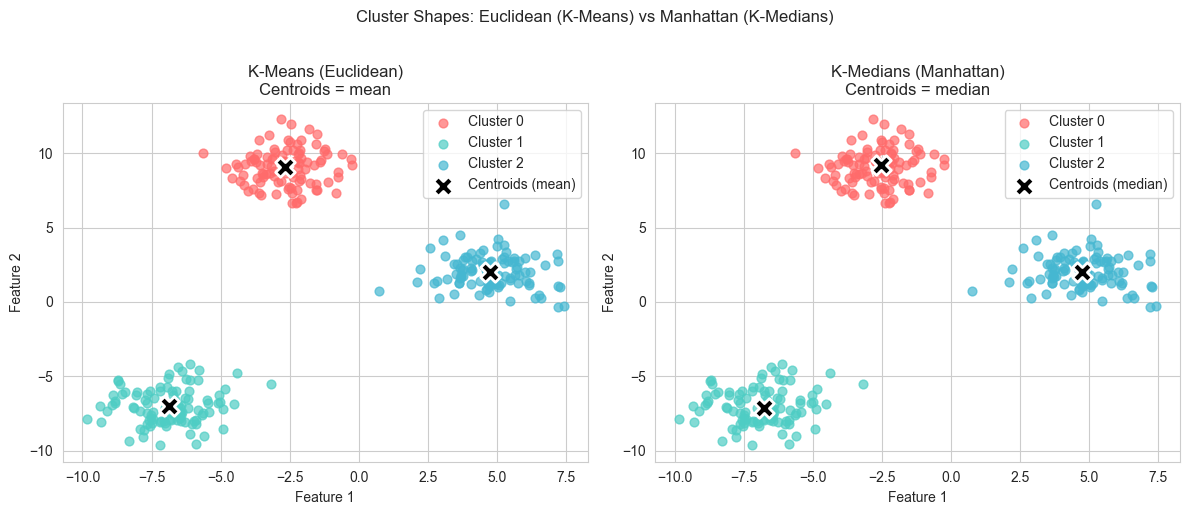

→ K-Means (mean) tends to spherical clusters; K-Medians (median) is more robust to outliers and can yield axis-aligned boundaries.


In [22]:
# Visualize cluster assignments: K-Means (Euclidean) vs K-Medians (Manhattan)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i in range(3):
    mask = labels_kmeans == i
    ax1.scatter(X[mask, 0], X[mask, 1], c=colors[i], s=40, alpha=0.7, label=f'Cluster {i}')
ax1.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            c='black', s=200, marker='X', edgecolors='white', linewidths=2, label='Centroids (mean)')
ax1.set_title('K-Means (Euclidean)\nCentroids = mean')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.legend()

for i in range(3):
    mask = labels_kmed == i
    ax2.scatter(X[mask, 0], X[mask, 1], c=colors[i], s=40, alpha=0.7, label=f'Cluster {i}')
ax2.scatter(centroids_kmed[:, 0], centroids_kmed[:, 1], 
            c='black', s=200, marker='X', edgecolors='white', linewidths=2, label='Centroids (median)')
ax2.set_title('K-Medians (Manhattan)\nCentroids = median')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.legend()
plt.suptitle('Cluster Shapes: Euclidean (K-Means) vs Manhattan (K-Medians)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print("→ K-Means (mean) tends to spherical clusters; K-Medians (median) is more robust to outliers and can yield axis-aligned boundaries.")

## 7. Impact of Outliers

- **Euclidean (L2)** squares the differences, so one **large** deviation contributes much more than many small ones. A single outlier can dominate the distance.
- **Manhattan (L1)** sums absolute differences, so one large deviation is only linearly worse. L1 is **more robust** to outliers.

We create a small dataset with an outlier and compare how distances from a reference point change under L2 vs L1, and visualize the effect.

In [23]:
# Reference point and normal points + one outlier
ref = np.array([0.0, 0.0])
points = np.array([[1, 1], [2, 1], [1, 2], [2, 2], [1.5, 1.5]])  # cluster near (1.5, 1.5)
outlier = np.array([10.0, 10.0])  # one far point
all_pts = np.vstack([points, outlier.reshape(1, -1)])
labels_pt = ['A', 'B', 'C', 'D', 'E', 'Outlier']

# Distances from ref to each point
euc_dists = [np.linalg.norm(p - ref) for p in all_pts]
man_dists = [np.sum(np.abs(p - ref)) for p in all_pts]

# Compare: how much does the outlier dominate?
print("Distances from reference (0,0) to each point:\n")
print(f"{'Point':<10} {'Euclidean':>12} {'Manhattan':>12}")
print("-" * 36)
for i, lab in enumerate(labels_pt):
    print(f"{lab:<10} {euc_dists[i]:>12.2f} {man_dists[i]:>12.2f}")

print("\n--- Effect of outlier ---")
print("Euclidean: outlier distance is", f"{euc_dists[-1] / np.mean(euc_dists[:-1]):.1f}", "x the average of normal points")
print("Manhattan: outlier distance is", f"{man_dists[-1] / np.mean(man_dists[:-1]):.1f}", "x the average of normal points")
print("\n→ L2 (Euclidean) amplifies large differences (squared), so the outlier dominates more. L1 (Manhattan) is more robust.")

Distances from reference (0,0) to each point:

Point         Euclidean    Manhattan
------------------------------------
A                  1.41         2.00
B                  2.24         3.00
C                  2.24         3.00
D                  2.83         4.00
E                  2.12         3.00
Outlier           14.14        20.00

--- Effect of outlier ---
Euclidean: outlier distance is 6.5 x the average of normal points
Manhattan: outlier distance is 6.7 x the average of normal points

→ L2 (Euclidean) amplifies large differences (squared), so the outlier dominates more. L1 (Manhattan) is more robust.


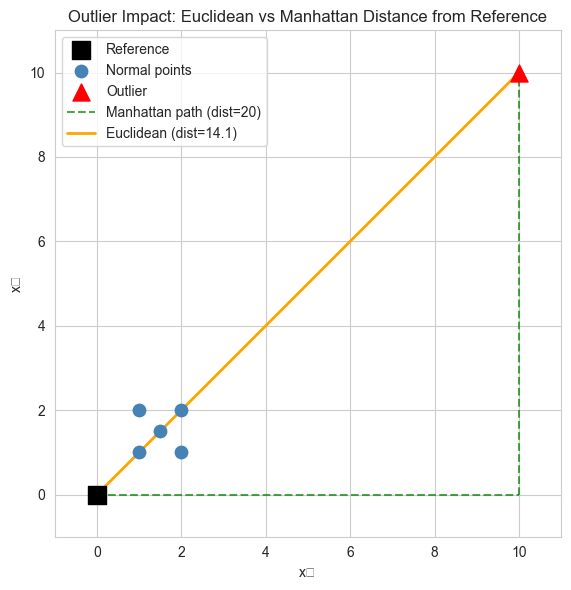

In [24]:
# Visualization: points and reference; show Euclidean vs Manhattan from ref to outlier
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(*ref, c='black', s=150, marker='s', label='Reference', zorder=5)
ax.scatter(points[:, 0], points[:, 1], c='steelblue', s=80, label='Normal points', zorder=5)
ax.scatter(*outlier, c='red', s=150, marker='^', label='Outlier', zorder=5)
# Draw Manhattan path from ref to outlier
ax.plot([0, 10], [0, 0], 'g--', alpha=0.7, linewidth=1.5)
ax.plot([10, 10], [0, 10], 'g--', alpha=0.7, linewidth=1.5, label=f'Manhattan path (dist={man_dists[-1]:.0f})')
# Draw Euclidean path
ax.plot([0, 10], [0, 10], 'orange', linestyle='-', linewidth=2, label=f'Euclidean (dist={euc_dists[-1]:.1f})')
ax.set_xlim(-1, 11)
ax.set_ylim(-1, 11)
ax.set_aspect('equal')
ax.legend()
ax.set_title('Outlier Impact: Euclidean vs Manhattan Distance from Reference')
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
plt.tight_layout()
plt.show()

## 8. Performance Comparison Summary

| Scenario | Euclidean (L2) | Manhattan (L1) |
|----------|----------------|----------------|
| **Grid movement** (e.g. city blocks, discrete steps) | Poor fit | Good fit |
| **Continuous geometry** (physical distance, smooth space) | Natural choice | Less natural |
| **Outlier sensitivity** | High (squared terms amplify) | Lower (linear) |
| **High-dimensional data** | Can degrade (all points seem equidistant) | Often more stable |
| **Computation** | Requires sqrt; differentiable | Simpler (abs); subgradient |

This table summarizes when each metric tends to perform better in practice.

In [25]:
# Display summary table as a pandas DataFrame for clarity
summary = pd.DataFrame({
    'Scenario': [
        'Grid movement (e.g. city blocks)',
        'Continuous geometry (physical distance)',
        'Outlier sensitivity',
        'High-dimensional data'
    ],
    'Euclidean (L2)': [
        'Poor',
        'Good',
        'High',
        'Can degrade'
    ],
    'Manhattan (L1)': [
        'Good',
        'Less natural',
        'Lower (more robust)',
        'Often more stable'
    ]
})
# Display table (display in Jupyter, else print)
try:
    from IPython.display import display
    display(summary)
except NameError:
    print(summary.to_string(index=False))

,Scenario,Euclidean (L2),Manhattan (L1)
0,Grid movement (e.g. city blocks),Poor,Good
1,Continuous geometry (physical distance),Good,Less natural
2,Outlier sensitivity,High,Lower (more robust)
3,High-dimensional data,Can degrade,Often more stable


## 9. Key Takeaways

### Use **Euclidean (L2)** when:
- **Geometric distance** matters (e.g. physical coordinates, spatial data).
- Features are **continuous** and you want the "natural" straight-line notion of closeness.
- There are **no extreme outliers** (or you preprocess/remove them).
- You are in **low to moderate dimensions** and want spherical/elliptical clusters (e.g. default K-Means).

### Use **Manhattan (L1)** when:
- Data lies on a **grid-like structure** (e.g. movement on a lattice, city blocks, discrete features).
- You have **sparse or high-dimensional** data where L2 can suffer from the "curse of dimensionality."
- **Robustness to outliers** is important (L1 does not square large errors).
- You want **axis-aligned** or diamond-shaped decision boundaries (e.g. K-Medians-style clustering).

---

**Summary:** The choice of distance metric is not just a technical detail—it encodes your assumption about what "similarity" or "closeness" means in your feature space. Experiment with both when using KNN, clustering, or any distance-based method, and let validation metrics and domain intuition guide your choice.